In [1]:
# retrieving functions from lindbladian.ipnyb
%run '/home/jovyan/NSERC 2026/[1] [lindbladian helper code] [may 19]/lindbladian.ipynb'

Note: you may need to restart the kernel to use updated packages.
  Using cached scienceplots-2.2.2-py3-none-any.whl.metadata (14 kB)
Using cached scienceplots-2.2.2-py3-none-any.whl (33 kB)
Note: you may need to restart the kernel to use updated packages.


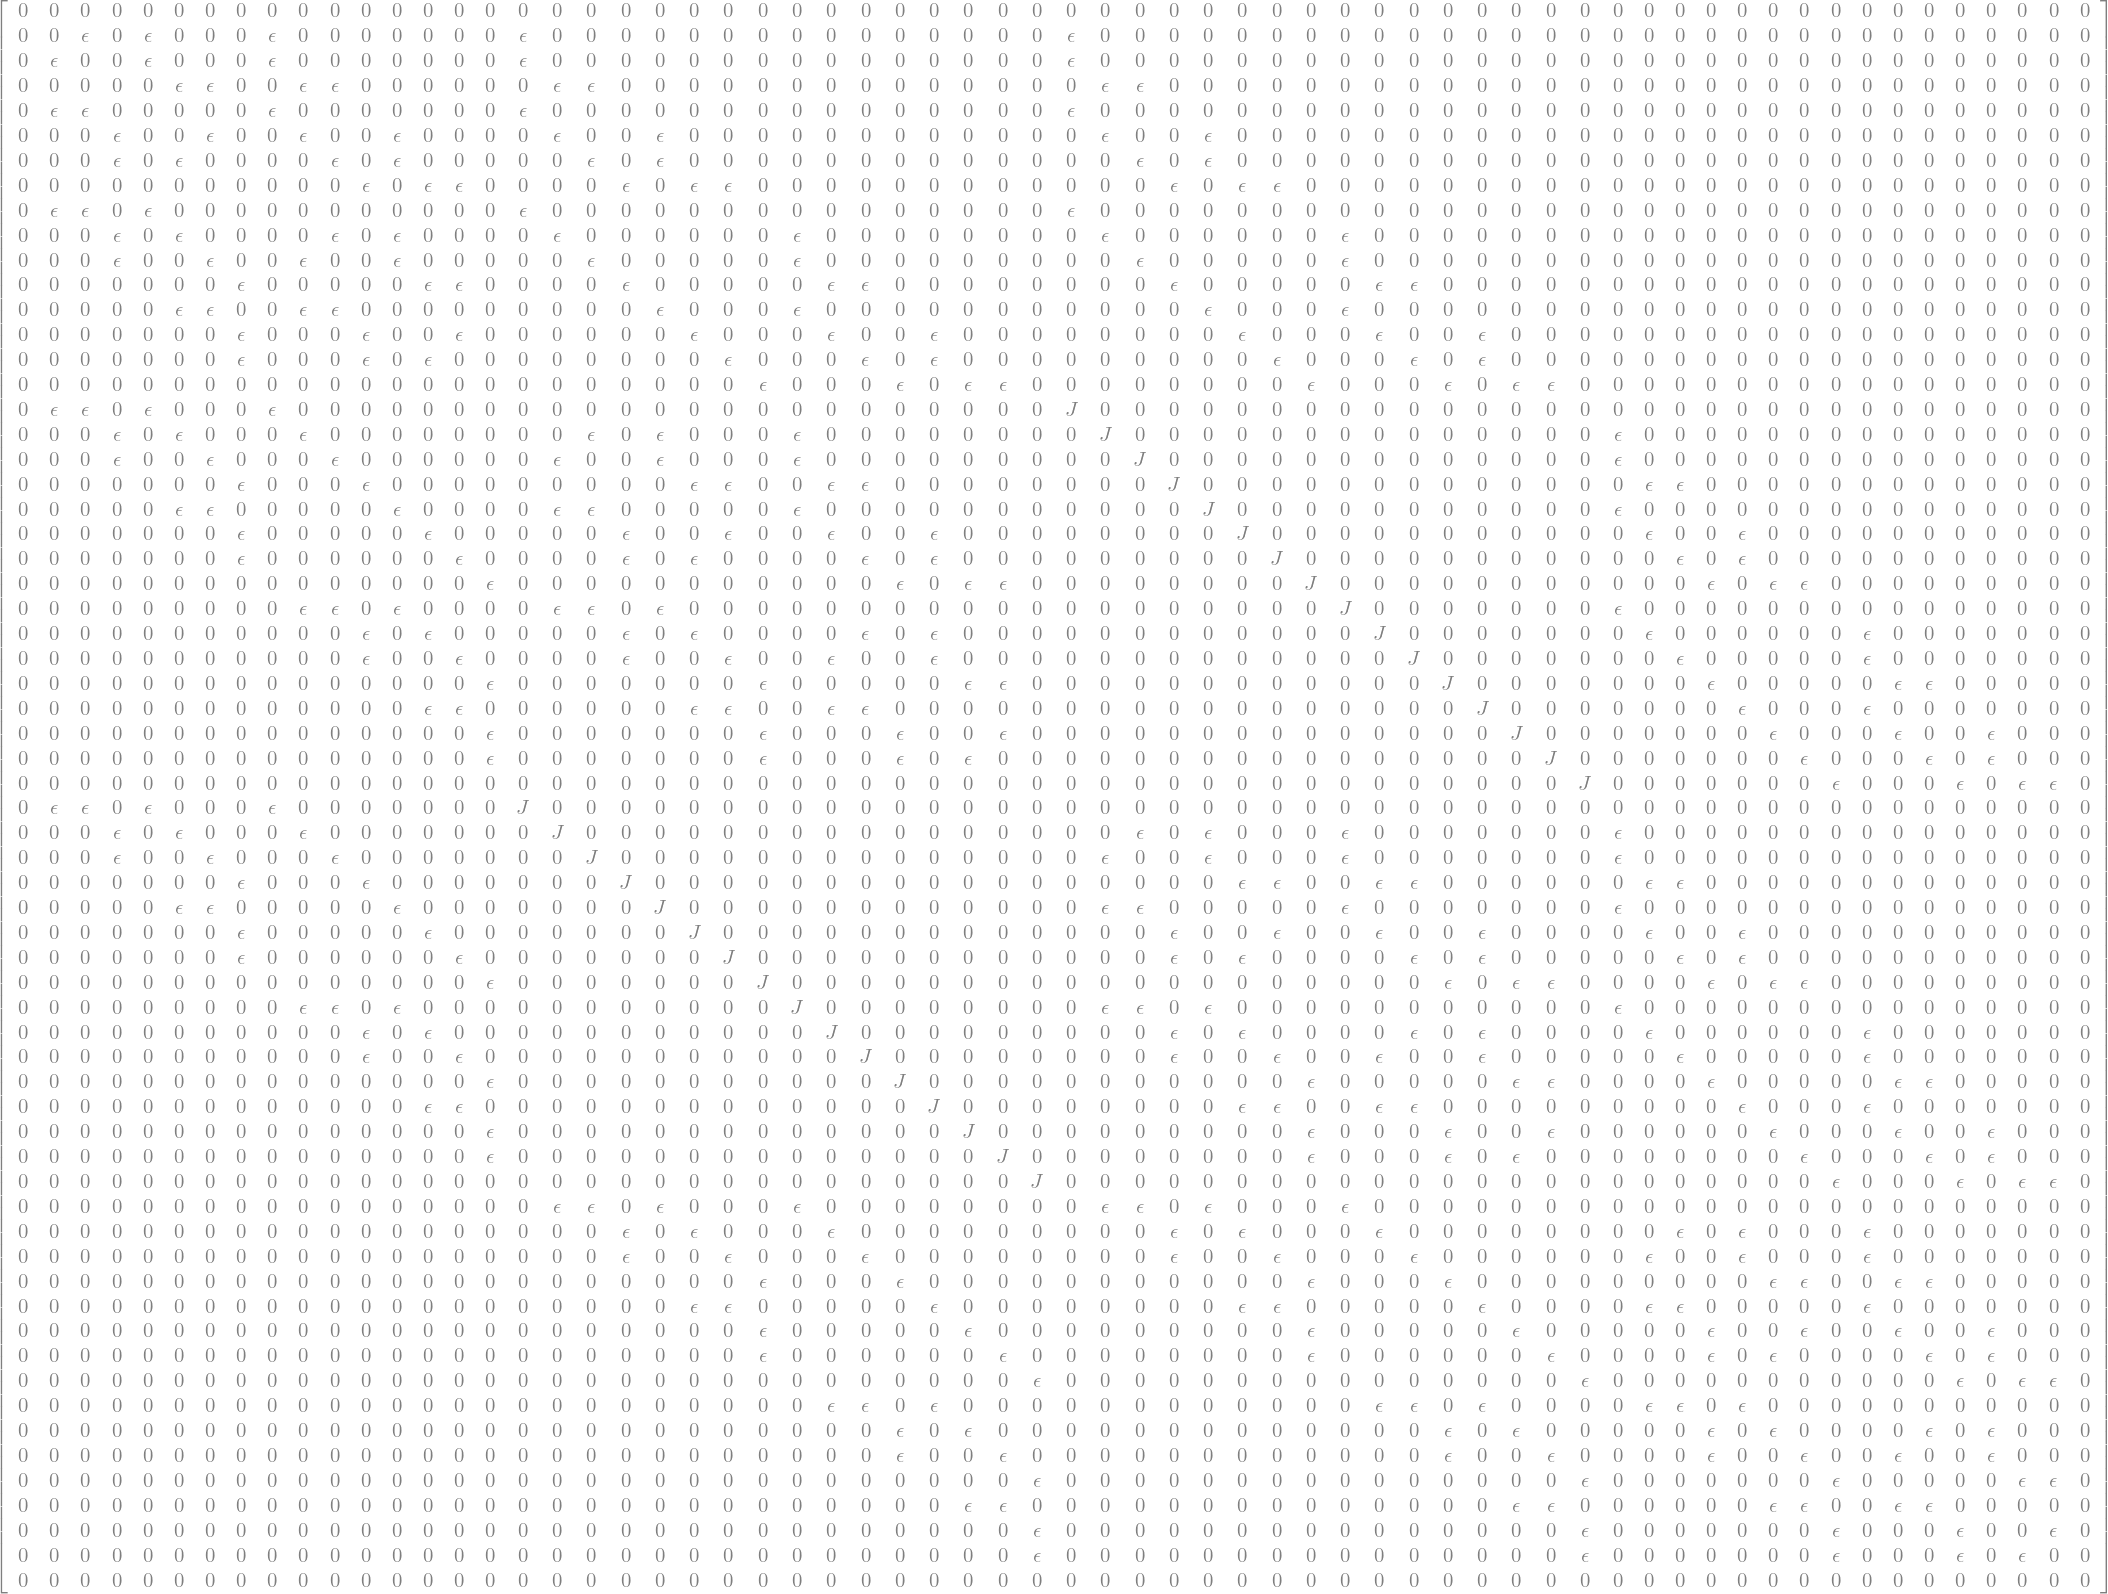

In [2]:
J = sp.Symbol("J", real=True, positive=True)
epsilon = sp.Symbol("epsilon", real=True, positive=True)
gamma = sp.Symbol("Gamma", real=True, positive=True)
delta = sp.Symbol("delta", real=True, positive=True)
sz = sp.Symbol("sigma_z", real=True, positive=True)

plt.style.use(['science', 'high-vis'])

N = 6 # number of sites
manifold = [3,5,6] # the rows/columns of the generic jump operators which correspond to our desired manifold

# building system hamiltonian
H_flipflop = sp.zeros(2**N, 2**N)
for j in range(N):
    for i in range(j):
        coeff = J if (i==0 and j==1) else epsilon
        H_flipflop += coeff*(sigma_plus(i,N)*sigma_minus(j,N)+sigma_plus(j,N)*sigma_minus(i,N))
H_flipflop

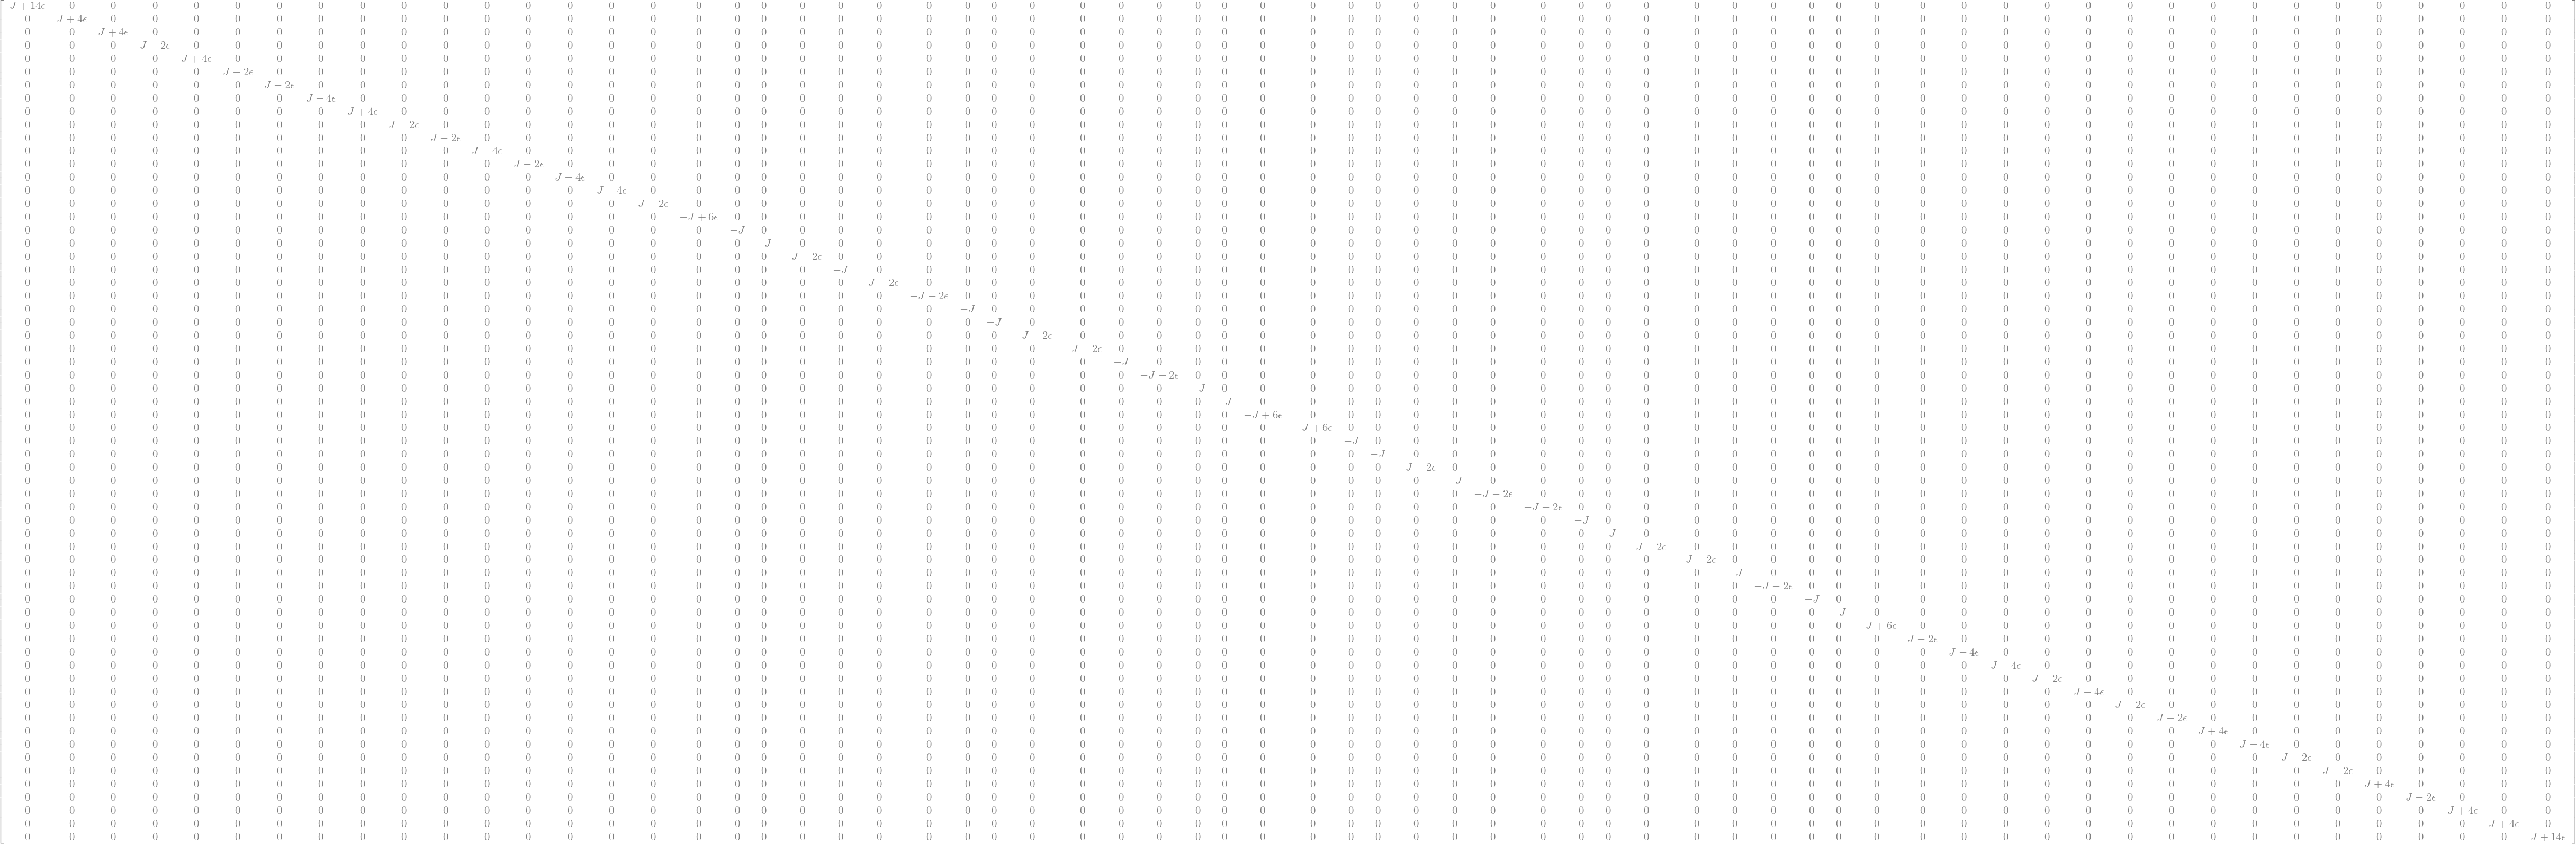

In [3]:
Hz = sp.zeros(2**N, 2**N)
for j in range(N):
    for i in range(j):
        coeff = J if (i==0 and j==1) else epsilon
        Hz += coeff*(sigma(sigma_z, i, N)*sigma(sigma_z, j, N))
Hz

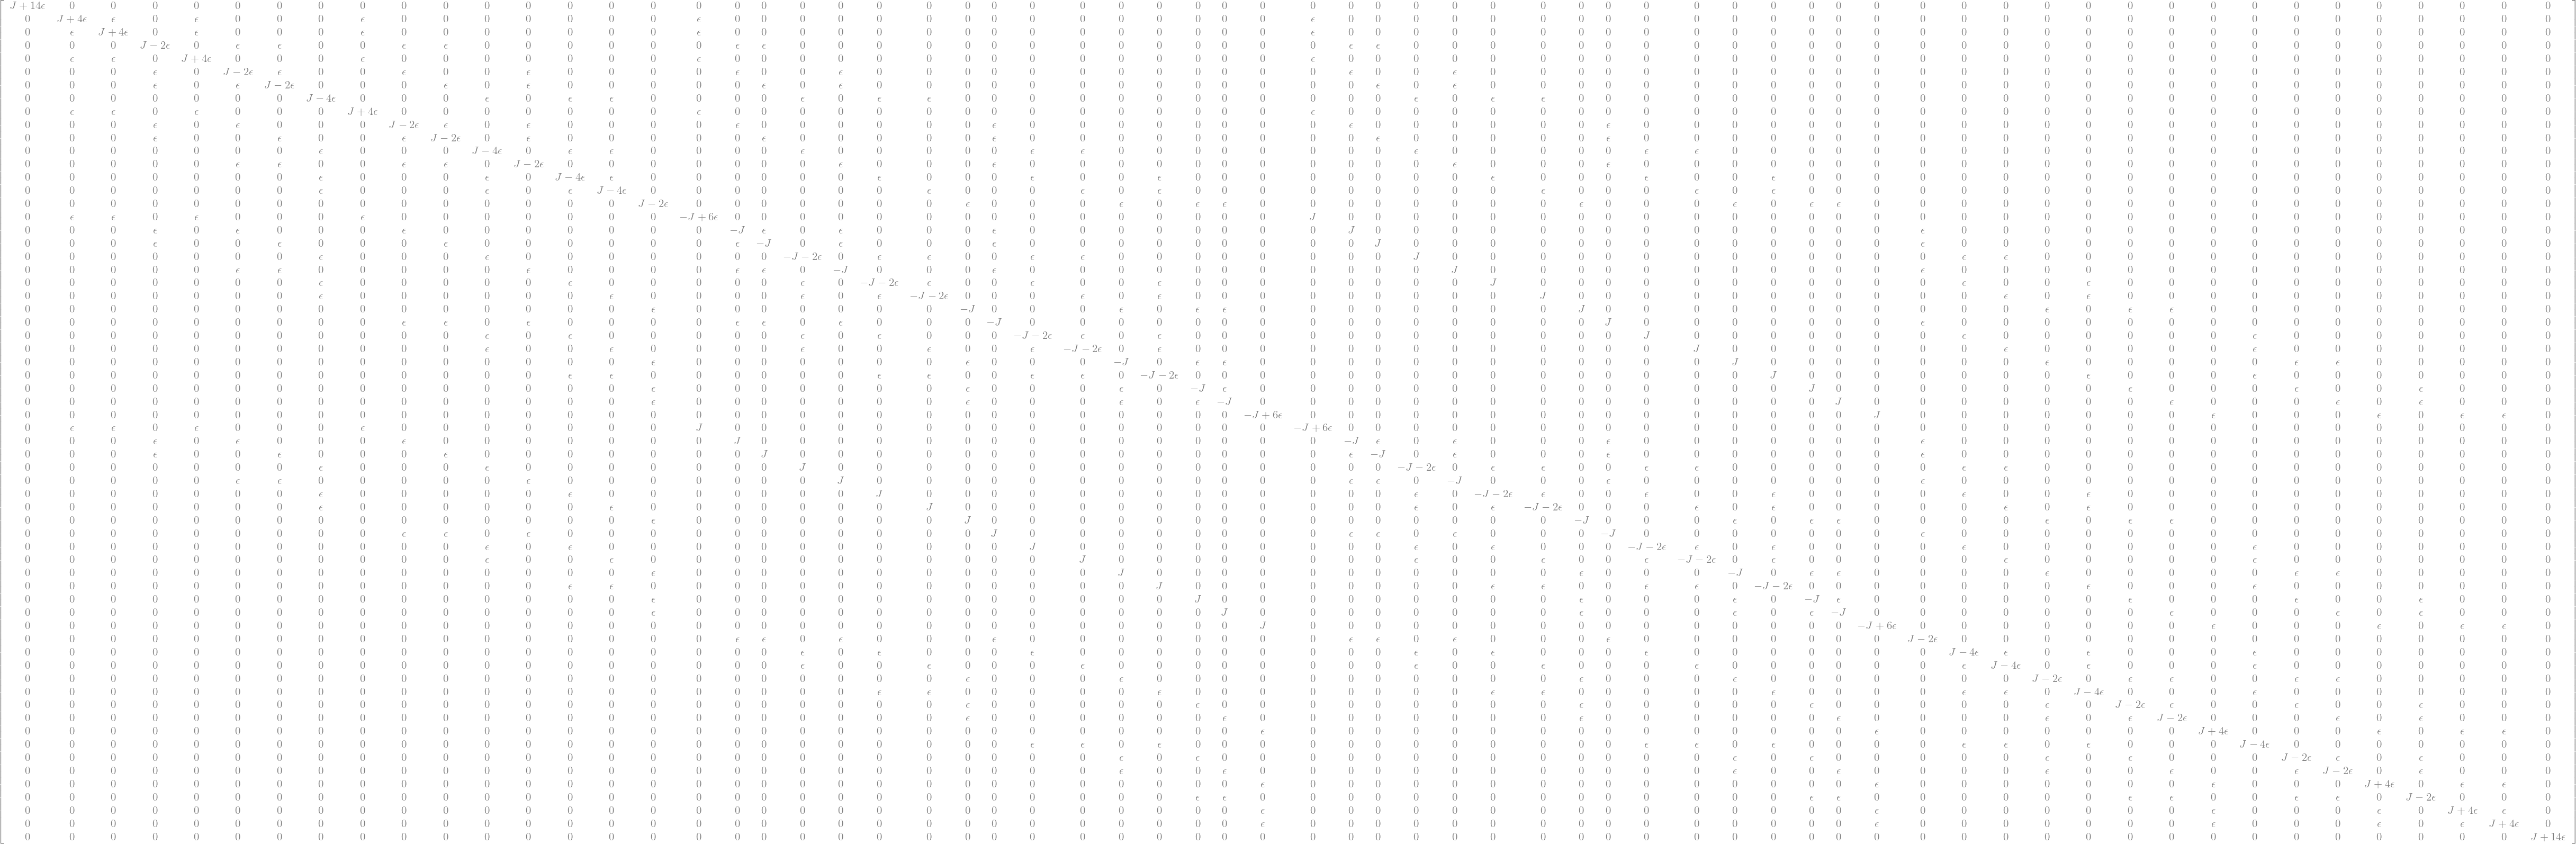

In [4]:
H_full = H_flipflop + Hz

H_full

In [5]:
# buildling matrices
sigma_z_1=np.array(sigma(sigma_z, 0, N)).astype(complex)
sigma_z_2=np.array(sigma(sigma_z, 1, N)).astype(complex)
sigma_z_3=np.array(sigma(sigma_z, 2, N)).astype(complex)

sigma_x_1=np.array(sigma(sigma_x, 0, N)).astype(complex)

# time evolution
def psi(t, H, psi_0):
    return scipy.linalg.expm(-1.0j*np.array(H).astype(complex)*t)@psi_0

# initial condition: $|\psi(t=0)⟩=|1⟩_1 + |0⟩_2 + |0⟩_3$

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


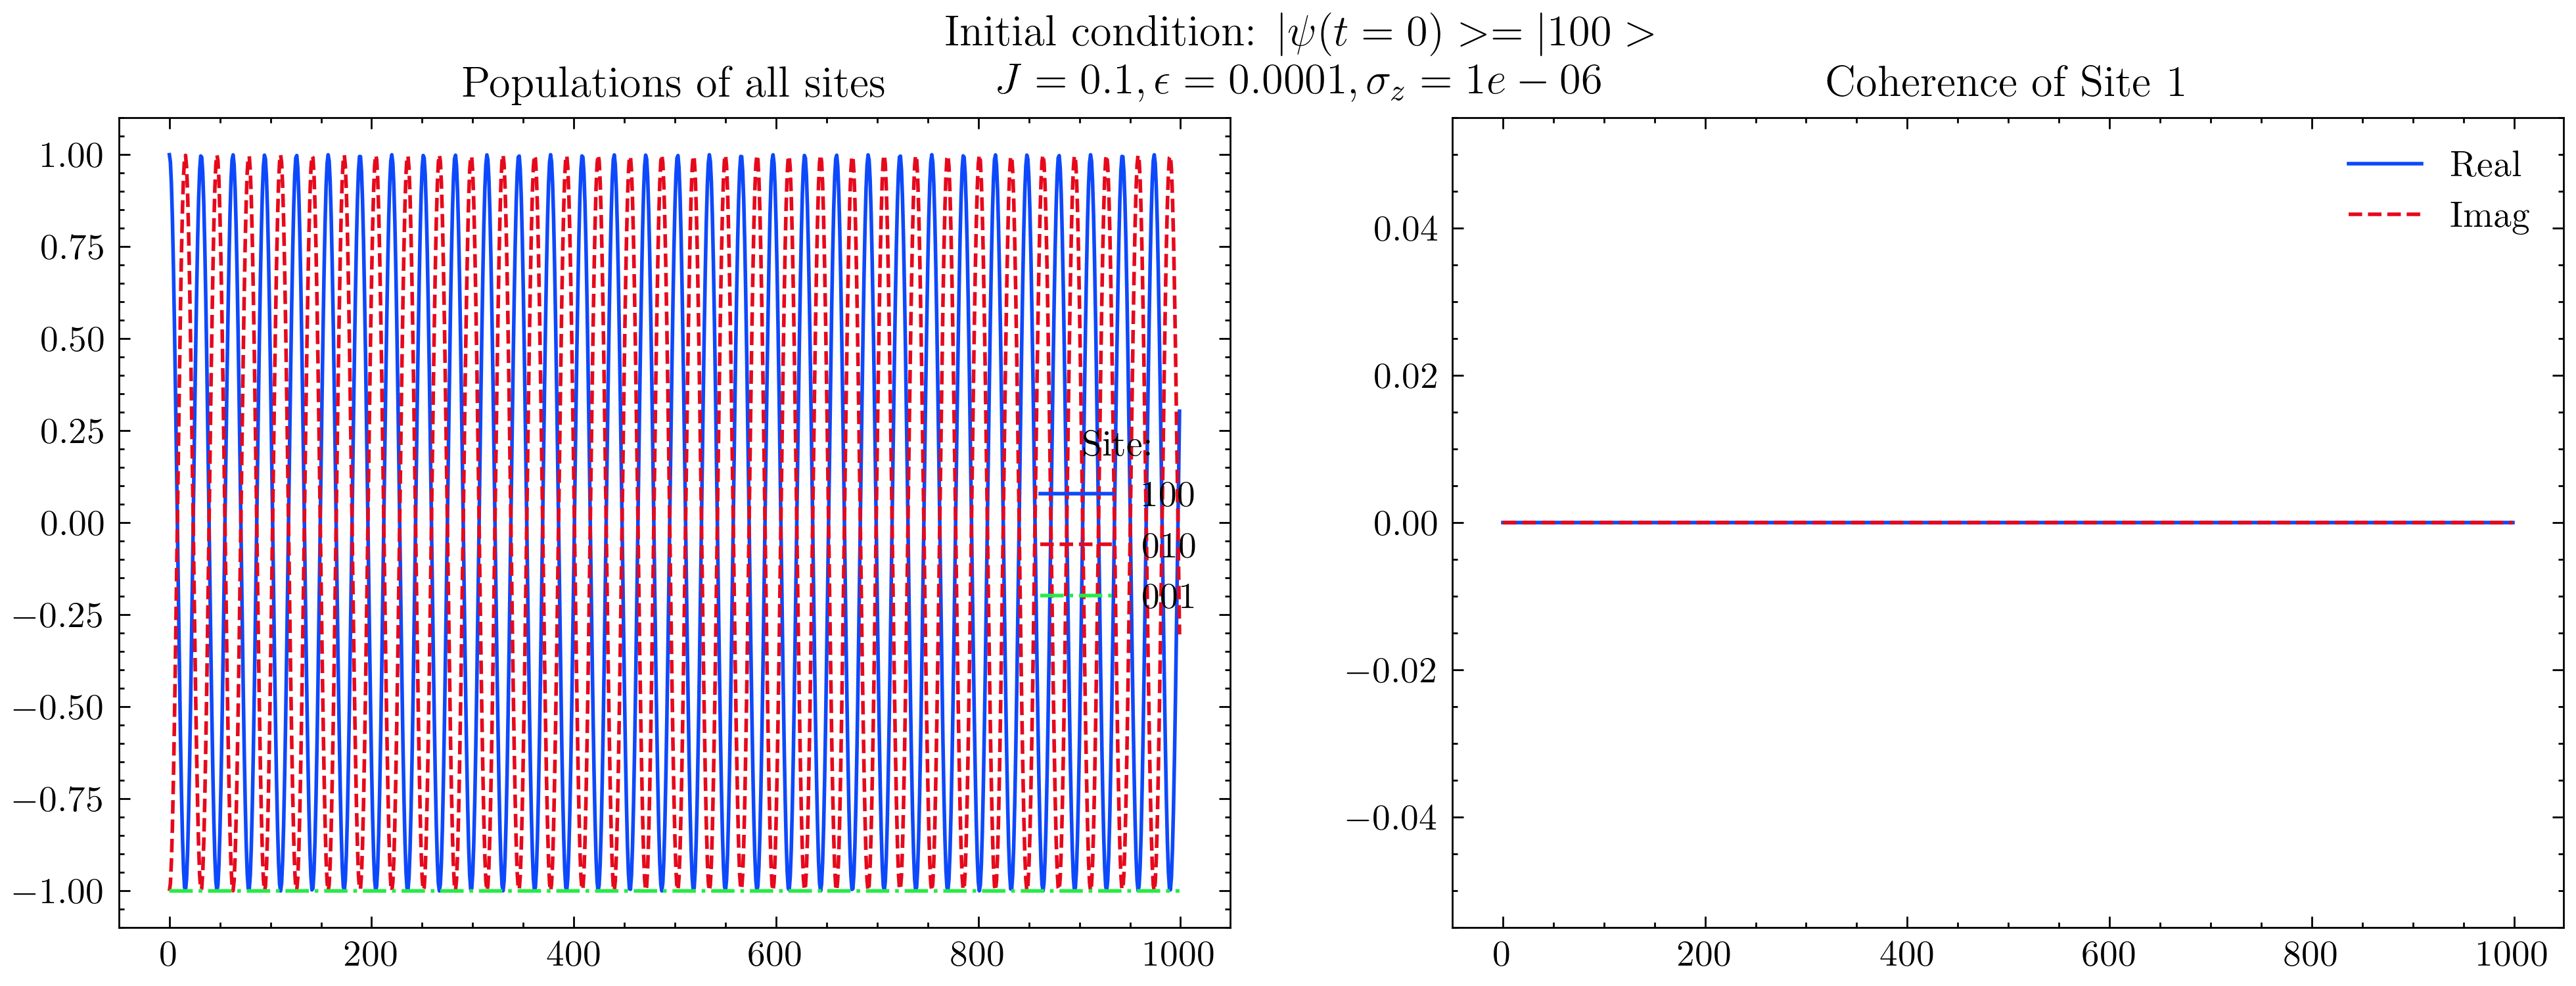

In [31]:
# simulation parameters
time_start = 0
time_stop = 1000
time_step = 1
times = np.arange(time_start, time_stop, time_step)


# constants
J_val = 0.1
epsilon_val = 1e-4
sz_val = 1e-6


# initial conidition
psi_0 = np.zeros(2**N)
psi_0[2**(N-1)]=1
print(psi_0)


# subbing values into H
H = H_full.subs({J:J_val, epsilon:epsilon_val, sz:sz_val})

# setting up fig
fig, axs = plt.subplots(1,2, figsize=(12,4))


# computing pops and cohs
pop1 = [-1*psi(time, H, psi_0).conj().transpose()@sigma_z_1@psi(time, H, psi_0) for time in times]
pop2 = [-1*psi(time, H, psi_0).conj().transpose()@sigma_z_2@psi(time, H, psi_0) for time in times]
pop3 = [-1*psi(time, H, psi_0).conj().transpose()@sigma_z_3@psi(time, H, psi_0) for time in times]
coh1 = [psi(time, H, psi_0).conj().transpose()@sigma_x_1@psi(time, H, psi_0) for time in times]


# plotting
axs[0].plot(times, pop1, label="100")
axs[0].plot(times, pop2, label="010")
axs[0].plot(times, pop3, label="001")
axs[0].legend(title="Site:")
axs[0].set_title("Populations of all sites")
axs[1].plot(times, np.real(coh1), label="Real")
axs[1].plot(times, np.imag(coh1), label="Imag")
axs[1].legend()
axs[1].set_title("Coherence of Site 1")

fig.suptitle("Initial condition: " + r"$|\psi(t=0)>=|100>$" + "\n" + fr"$J={J_val}, \epsilon={epsilon_val}, \sigma_z={sz_val}$")

fig.savefig("initially in 1.pdf")


[0.70710678 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.70710678 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]


/opt/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


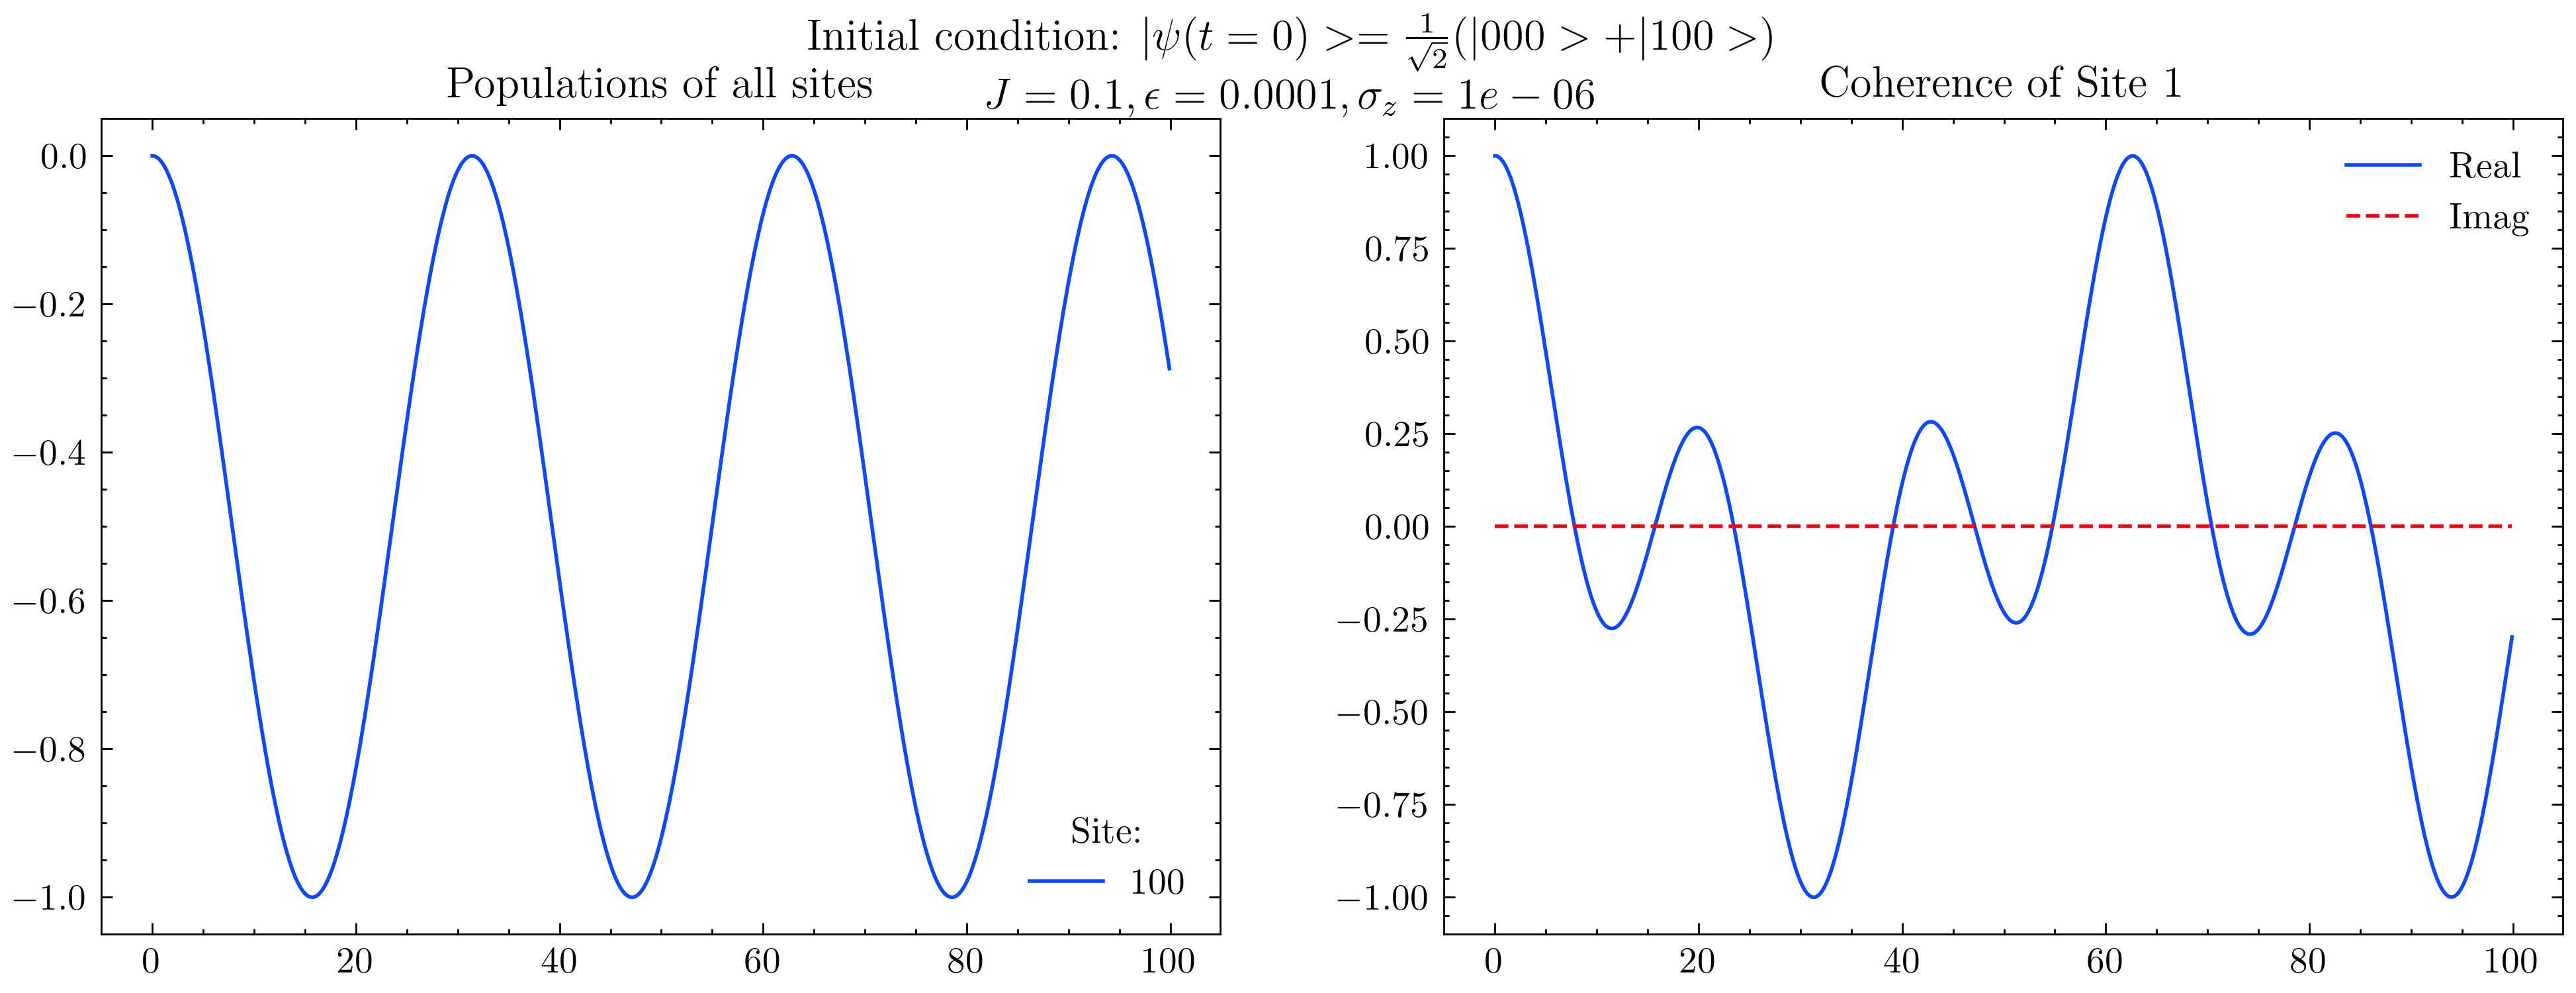

In [6]:
# simulation parameters
time_start = 0
time_stop = 100
time_step = 0.1
times = np.arange(time_start, time_stop, time_step)


# constants
J_val = 0.1
epsilon_val = 1e-4
sz_val = 1e-6


# initial conidition
psi_0 = np.zeros(2**N)
psi_0[2**(N-1)]=1/np.sqrt(2)
psi_0[0]=1/np.sqrt(2)
print(psi_0)


# subbing values into H
H = H_full.subs({J:J_val, epsilon:epsilon_val, sz:sz_val})

# setting up fig
fig, axs = plt.subplots(1,2, figsize=(12,4))


# computing pops and cohs
pop1 = [-1*psi(time, H, psi_0).conj().transpose()@sigma_z_1@psi(time, H, psi_0) for time in times]
coh1 = [psi(time, H, psi_0).conj().transpose()@sigma_x_1@psi(time, H, psi_0) for time in times]


# plotting
axs[0].plot(times, pop1, label="100")
axs[0].legend(title="Site:")
axs[0].set_title("Populations of all sites")
axs[1].plot(times, np.real(coh1), label="Real")
axs[1].plot(times, np.imag(coh1), label="Imag")
axs[1].legend()
#axs[1].ticklabel_format(axis='x', style='sci', scilimits=(0, 0)) 
axs[1].set_title("Coherence of Site 1")

fig.suptitle("Initial condition: " + r"$|\psi(t=0)>=\frac{1}{\sqrt{2}}(|000> +|100>)$" + "\n" + fr"$J={J_val}, \epsilon={epsilon_val}, \sigma_z={sz_val}$")

fig.savefig("initially in superposition.pdf")


# eigenvalue analysis

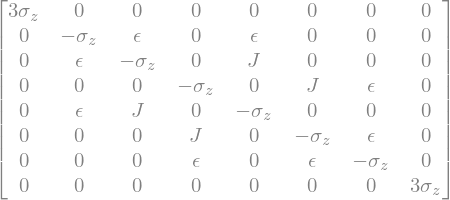

In [85]:
H_full

In [98]:
H, rho = lindbladian(8, H=H_full, dissipative=False)

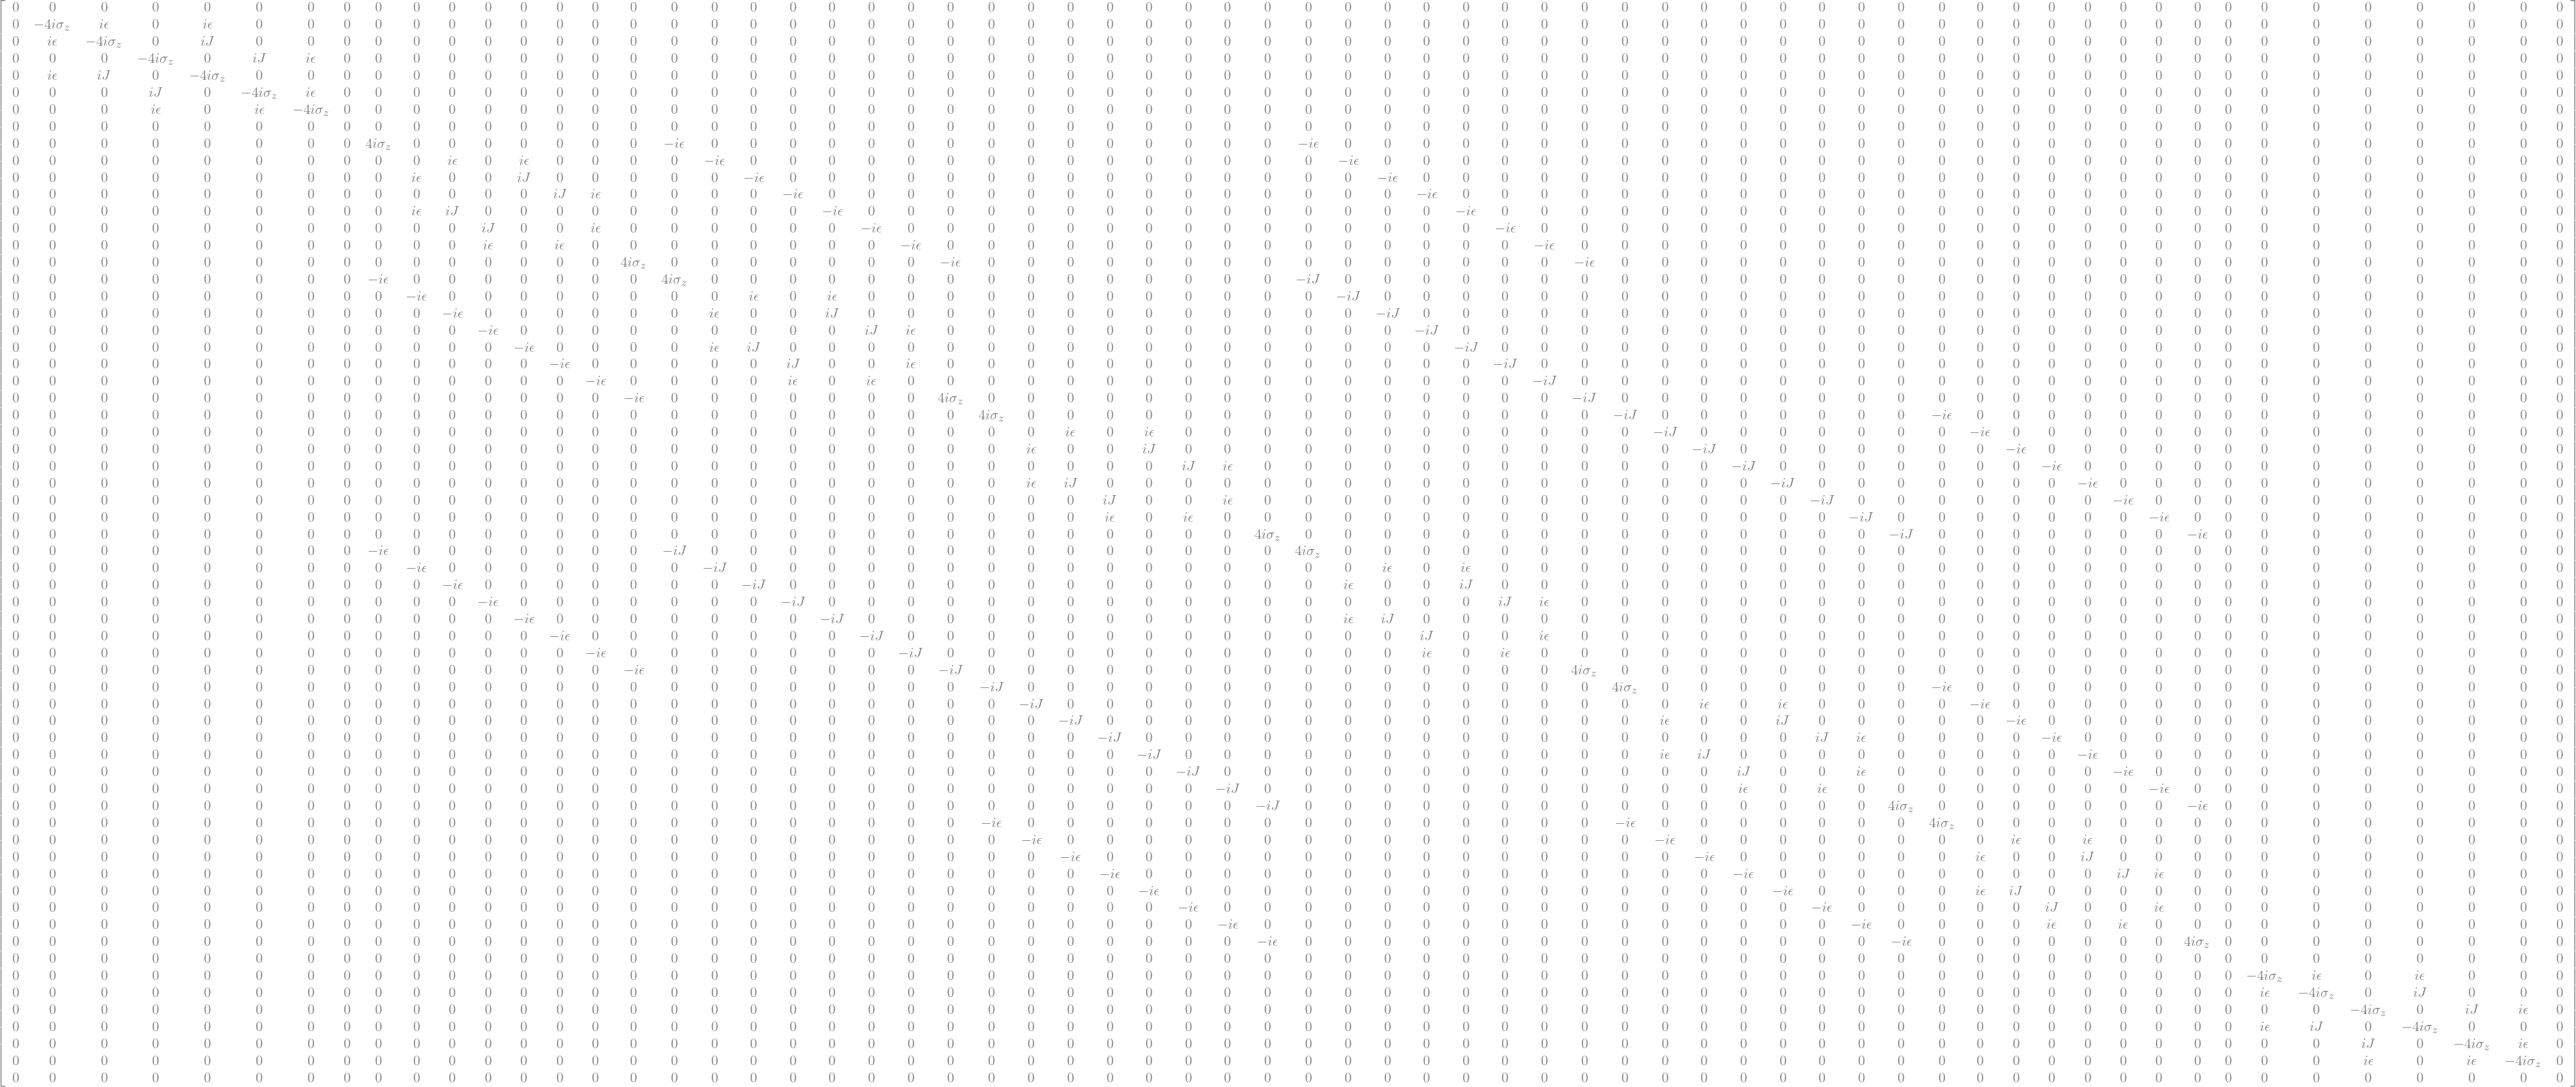

In [99]:
H

In [101]:
evals = []

for val, i in H.eigenvals().items():
    evals.append(val)

In [102]:
for val in evals:
    display(val.subs({J:0.1, epsilon:1e-4, sz:1e-6}))
    print("++++++++++++++++++++++")

++++++++++++++++++++++


++++++++++++++++++++++


++++++++++++++++++++++


++++++++++++++++++++++


++++++++++++++++++++++


++++++++++++++++++++++


++++++++++++++++++++++


++++++++++++++++++++++


++++++++++++++++++++++


++++++++++++++++++++++


++++++++++++++++++++++


++++++++++++++++++++++


++++++++++++++++++++++


++++++++++++++++


++++++++++++++++


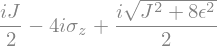

++++++++++++++++


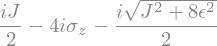

++++++++++++++++


++++++++++++++++


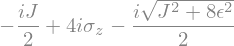

++++++++++++++++


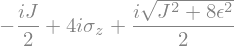

++++++++++++++++


++++++++++++++++


++++++++++++++++


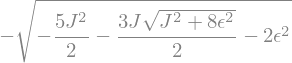

++++++++++++++++


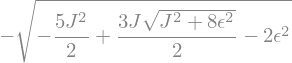

++++++++++++++++


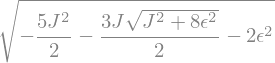

++++++++++++++++


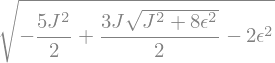

++++++++++++++++


In [103]:
for val in evals:
    display(val)
    print("++++++++++++++++")